*Planned detection/algorithm flow*

**For point anomalies:**
telemetry data (only the first column) -> IQR -> analyze results

**For contextual anomalies**
telemetry data with all the features -> k-NN and LOF -> analyze results


First import dataset from kaggle

In [3]:
import os
import zipfile
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.ensemble import IsolationForest
import time

from dotenv import load_dotenv

load_dotenv()  # load .env variables into the session

True

In [2]:
kaggle_username = os.getenv("KAGGLE_USERNAME")
kaggle_key = os.getenv("KAGGLE_KEY")

In [ ]:
os.system("kaggle datasets download patrickfleith/nasa-anomaly-detection-dataset-smap-msl") # downloaded as zip file

Dataset URL: https://www.kaggle.com/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl
License(s): copyright-authors


 96%|█████████▋| 79.0M/82.0M [00:05<00:00, 19.9MB/s]

100%|██████████| 82.0M/82.0M [00:05<00:00, 15.7MB/s]


0

In [ ]:
with zipfile.ZipFile("nasa-anomaly-detection-dataset-smap-msl.zip", "r") as zip_ref:
    zip_ref.extractall("./data")

In [4]:
p_1 = np.load("data/data/data/test/E-13.npy")

print(p_1.shape)

m_6 = np.load("data/data/data/test/M-6.npy")

print(m_6[:, 0])

(8640, 25)
[ -1.          -1.          -1.         ... 129.89189189 129.89189189
 129.89189189]


Get channels that belong to MSL measures and SMAP measures

In [5]:
labeled_data = pd.read_csv("data/labeled_anomalies.csv")
chan_and_spacecraft =  labeled_data[["chan_id" , "spacecraft"]]

msl_data = chan_and_spacecraft[chan_and_spacecraft["spacecraft"] == "MSL"]
smap_data = chan_and_spacecraft[chan_and_spacecraft["spacecraft"] == "SMAP"]

msl_channels = msl_data["chan_id"].to_list()
smap_channels = smap_data["chan_id"].to_list()

print(smap_channels)
print(msl_channels)

['P-1', 'S-1', 'E-1', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8', 'E-9', 'E-10', 'E-11', 'E-12', 'E-13', 'A-1', 'D-1', 'P-2', 'P-3', 'D-2', 'D-3', 'D-4', 'A-2', 'A-3', 'A-4', 'G-1', 'G-2', 'D-5', 'D-6', 'D-7', 'F-1', 'P-4', 'G-3', 'T-1', 'T-2', 'D-8', 'D-9', 'F-2', 'G-4', 'T-3', 'D-11', 'D-12', 'B-1', 'G-6', 'G-7', 'P-7', 'R-1', 'A-5', 'A-6', 'A-7', 'D-13', 'P-2', 'A-8', 'A-9', 'F-3']
['M-6', 'M-1', 'M-2', 'S-2', 'P-10', 'T-4', 'T-5', 'F-7', 'M-3', 'M-4', 'M-5', 'P-15', 'C-1', 'C-2', 'T-12', 'T-13', 'F-4', 'F-5', 'D-14', 'T-9', 'P-14', 'T-8', 'P-11', 'D-15', 'D-16', 'M-7', 'F-8']


There are multiple channel measurements for the spacecrafts. We need to check the shapes of the data.

In [6]:
def check_shape_and_attribute_numbers(spacecraft_channels, exp_attr_num):
    for channel in spacecraft_channels:
        dir = f"data/data/data/test/{channel}.npy"
        raw_data = np.load(dir)

        if raw_data.shape[1] != exp_attr_num: 
            print("Inconsistent attribute numbers.")
            return

    print("Consistent attribute number.")
        

#### The number of attributes across different channels of the same spacecraft are consistent.

55 attributes for MSL and 25 attributes for SMAP

In [7]:
# check the shape of each channel and attribute numbers
check_shape_and_attribute_numbers(smap_channels, 25) 
check_shape_and_attribute_numbers(msl_channels, 55)


Consistent attribute number.
Consistent attribute number.


Point anomalies are single values that fall within low-density regions of values, collective anomalies indicate that a sequence of values is anomalous 
rather than any single value by itself, and contextual anomalies are single values that do not fall within low-density regions yet are anomalous with 
regard to local values. (Hundman et al)


In this study i will explor point and contextual anomalies

In [8]:
import re

def parse_class(class_str):
    # list return ediyor, stringden ayrıştırıyoruz
    return re.findall(r'point|contextual', class_str)

labeled_data['class_parsed'] = labeled_data['class'].apply(parse_class)

# check if worked
print(labeled_data['class_parsed'].head())

0    [contextual, contextual, contextual]
1                                 [point]
2                [contextual, contextual]
3                                 [point]
4                                 [point]
Name: class_parsed, dtype: object


Rows with mixed anomalies will be out of scope because this study uses explicitly different methods for point anomaly and contextual anomaly detections.

In [9]:
# extract data that only has "point" or "contextual" anomalies
# this way we exclude any data point that has mixed anomalies - data pruning
point_channels = labeled_data[labeled_data['class_parsed'].apply(lambda x: all(c == 'point' for c in x))]['chan_id'].tolist()
contextual_channels = labeled_data[labeled_data['class_parsed'].apply(lambda x: all(c == 'contextual' for c in x))]['chan_id'].tolist()

print(f"Point channels: {point_channels}")
print(f"Contextual channels: {contextual_channels}")

Point channels: ['S-1', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8', 'E-9', 'A-1', 'D-1', 'P-2', 'P-3', 'D-2', 'D-3', 'D-4', 'G-2', 'D-5', 'D-6', 'D-7', 'F-1', 'P-4', 'G-3', 'T-2', 'D-8', 'D-9', 'F-2', 'G-4', 'T-3', 'D-11', 'D-12', 'B-1', 'G-6', 'R-1', 'A-5', 'A-6', 'D-13', 'P-2', 'M-6', 'S-2', 'P-10', 'T-4', 'T-5', 'P-15', 'F-4', 'F-5', 'D-14', 'T-9', 'P-14', 'P-11', 'D-15', 'M-7']
Contextual channels: ['P-1', 'E-1', 'E-10', 'E-11', 'E-12', 'E-13', 'A-2', 'A-3', 'A-4', 'G-1', 'P-7', 'A-7', 'A-8', 'A-9', 'F-3', 'M-1', 'M-2', 'F-7', 'M-3', 'M-4', 'M-5', 'T-12', 'T-13', 'T-8', 'D-16', 'F-8']


In [10]:
def parse_anomaly_sequences(sequence_str):
    # find all pairs of numbers in the string
    pairs = re.findall(r'\[(\d+),\s*(\d+)\]', sequence_str)
    # convert to list of [int, int]
    return [[int(start), int(end)] for start, end in pairs]

labeled_data['anomaly_sequences_parsed'] = labeled_data['anomaly_sequences'].apply(parse_anomaly_sequences)
print(labeled_data['anomaly_sequences_parsed'].head())

0    [[2149, 2349], [4536, 4844], [3539, 3779]]
1                                [[5300, 5747]]
2                  [[5000, 5030], [5610, 6086]]
3                                [[5598, 6995]]
4                                [[5094, 8306]]
Name: anomaly_sequences_parsed, dtype: object


We will visualize the data. 

Based on the num_values attribute in the labeled_anomalies.csv file, it is found out that the data in the /data/test directory are the full-length telemetry data, where /data/train directory are only parts that are seperated for training for deep-learning-based approaches.

In [ ]:
# visualize the data using the labeled csv file to understand the anomalies and the nature of measurements.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def plot_spacecraft_channels(spacecraft_channels, spacecraft_name, labeled_data):
    """
    Plots the sensor reading (column 0) for each channel of a spacecraft.
    Highlights anomalous regions in red using ground truth labels.
    """
    n_channels = len(spacecraft_channels)
    fig, axes = plt.subplots(n_channels, 1, figsize=(15, n_channels * 2))
    fig.suptitle(f"{spacecraft_name} — Sensor Readings Across All Channels", 
                 fontsize=14, fontweight='bold', y=1.01)
    
    for i, channel in enumerate(spacecraft_channels):
        # Load test data (anomalies are in test set)
        dir = f"data/data/data/test/{channel}.npy"
        raw_data = np.load(dir)
        sensor_reading = raw_data[:, 0]  # column 1 — the behavioral attribute
        
        ax = axes[i] if n_channels > 1 else axes
        
        # Plot sensor reading
        ax.plot(sensor_reading, color='steelblue', linewidth=0.8, label='Sensor Reading')
        
        # Highlight anomaly regions from labels
        channel_label = labeled_data[labeled_data['chan_id'] == channel]
        if not channel_label.empty:
            anomaly_sequences = eval(channel_label['anomaly_sequences'].values[0])
            for seq in anomaly_sequences:
                ax.axvspan(seq[0], seq[1], alpha=0.3, color='red', label='Anomaly')
        
        ax.set_ylabel(channel, fontsize=8, rotation=0, labelpad=40)
        ax.set_xlim(0, len(sensor_reading))
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(True, alpha=0.3)
    
    # Add legend once
    normal_patch = mpatches.Patch(color='steelblue', label='Normal')
    anomaly_patch = mpatches.Patch(color='red', alpha=0.3, label='Anomaly')
    fig.legend(handles=[normal_patch, anomaly_patch], 
               loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f"{spacecraft_name}_channels_overview.png", 
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved as {spacecraft_name}_channels_overview.png")


# Plot all SMAP channels
plot_spacecraft_channels(smap_channels, "SMAP", labeled_data)

# Plot all MSL channels
plot_spacecraft_channels(msl_channels, "MSL", labeled_data)

In [26]:
def plot_channel_reading(chan: str, title: str):
    
    dir = f"data/data/data/test/{chan}.npy"
    raw_data = np.load(dir)
    sensor_reading = raw_data[:, 0]

    plt.figure()
    plt.plot(sensor_reading, color='steelblue', linewidth=0.8, label='Sensor Reading')

    # Highlight anomaly regions
    channel_label = labeled_data[labeled_data['chan_id'] == chan]
    if not channel_label.empty:
        anomaly_sequences = channel_label['anomaly_sequences_parsed'].values[0]

        for i, (start, end) in enumerate(anomaly_sequences):
            if i == 0:
                plt.axvspan(start, end, alpha=0.3, color='red', label='Anomaly')
            else:
                plt.axvspan(start, end, alpha=0.3, color='red')

    plt.xlabel("Time Step")
    plt.ylabel("Measured Telemetry Data")
    plt.title(title + " " + chan)
    plt.legend()
    plt.show()

All the plots for SMAP and MSL data can be found in *SMAP_channels_overview.png* and *MSL_channels_overview.png*

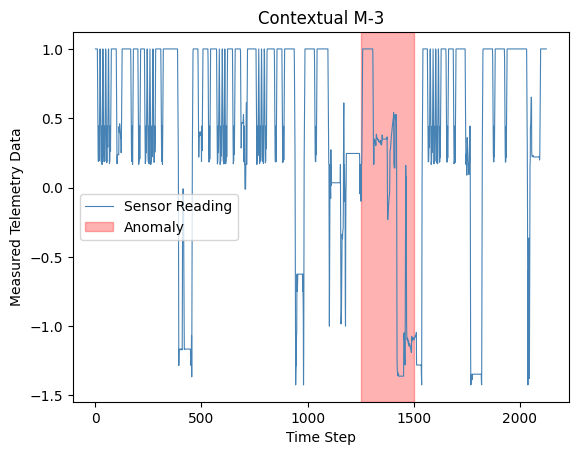

In [29]:
# Quick visualization for one point and one contextual anomaly channel.
plot_channel_reading("M-3", "Contextual")

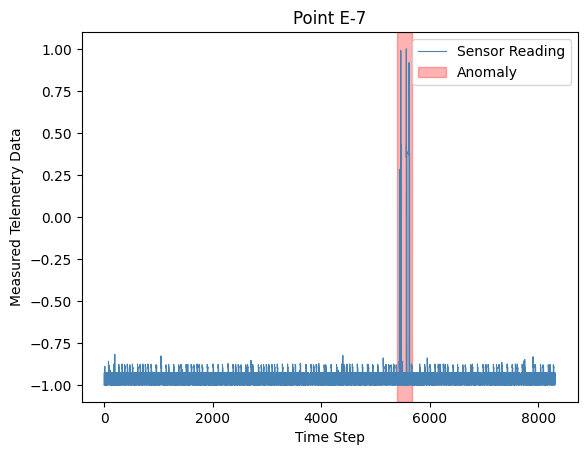

In [84]:
plot_channel_reading("E-7", "Point")

### 1. POINT ANOMALIES

Below, we define the methods that will be used to detect the point anomalies.
Some of these methods/functions, like k-NN, will also be used during the contextual anomaly detection section.

In [196]:
# IQR calculation

# tek channel datası verilecek parametre olarak.
def IQR_calc(data):
    # 2- get the %25 and %75 of data IQR ranges
    # 3- calculate IQR and bounds

    start_time = time.time()

    data = data[:, 0]
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)

    IQR = Q3-Q1

    lower_bound = Q1 - 1.5*IQR
    higher_bound = Q3 + 1.5*IQR

    predicted_labels = ((data < lower_bound) | (data > higher_bound)).astype(int)
    
    total_time = time.time() - start_time

    """outliers = [] 

        for i in data:
            if i < lower_bound or i > higher_bound:
                outliers.append(i)

        return outliers"""
    #print(lower_bound, higher_bound)
    #print(sorted_data)

    # hangi indexte outlier olduğunu çıkarıyor.
    outlier_timesteps = (np.where(predicted_labels == 1)[0]).tolist()

    results = {
        'total_time': total_time,
        'is_outlier': predicted_labels,
        'outlier_timesteps' : outlier_timesteps
    }

    return results
   


In [197]:
# test the IQR method for one channel first
e_7 = np.load("data/data/data/test/E-7.npy")

results = IQR_calc(e_7)

print(len(results["outlier_timesteps"]))
# how many outliers found
print(results["outlier_timesteps"])


40
[195, 5440, 5441, 5442, 5443, 5444, 5445, 5465, 5466, 5467, 5468, 5469, 5470, 5471, 5472, 5473, 5474, 5475, 5567, 5568, 5569, 5570, 5571, 5572, 5573, 5574, 5575, 5576, 5577, 5618, 5619, 5620, 5621, 5622, 5623, 5624, 5625, 5626, 5627, 5628]


We want to group the detected indices together into windows since the anomalies are labeled as sequences. This way we can do better evaluation.

Since the minimum gap is of length 10, we will choose the default gap_threshold as 10

In [99]:
# for determining a gap threshold for combining the windows, we will calcualte the min gap in the labeled anomaly windows
def calc_min_gap(labeled_data):
    anomaly_seq = labeled_data['anomaly_sequences_parsed']
    min_gap = float('inf')
    for anomaly in anomaly_seq:
        for a in anomaly:
            gap = a[1]-a[0]
            if gap<min_gap: min_gap = gap

    return min_gap

In [100]:
gap = calc_min_gap(labeled_data)
gap

10

In [82]:
def merge_to_windows(predicted_labels, gap_threshold=10):
    """Merge nearby flagged timesteps into windows"""
    anomaly_timesteps = np.where(predicted_labels == 1)[0]
    if len(anomaly_timesteps) == 0:
        return []
    windows = []
    start = anomaly_timesteps[0]
    end = anomaly_timesteps[0]
    for t in anomaly_timesteps[1:]:
        if t - end <= gap_threshold:
            end = t
        else:
            windows.append([int(start), int(end)])
            start = t
            end = t
    windows.append([int(start), int(end)])
    return windows

In [205]:
windows = merge_to_windows(results['is_outlier'])
print(windows)

[[195, 195], [5440, 5445], [5465, 5475], [5567, 5577], [5618, 5628]]


### 2. CONTEXTUAL ANOMALIES

These metrics are utilized for conetxtual anomalies: K-NN and LOF

The measured telemetry values are being scaled in the range [0,1] for better performance.

In [202]:
# helpers

def scores_to_labels(scores, threshold_percentile=95):
    """Convert anomaly scores to binary labels"""
    threshold = np.percentile(scores, threshold_percentile)
    return (scores >= threshold).astype(int), (np.where(scores >= threshold)[0]).tolist()

#### k-NN

In [207]:
from sklearn.preprocessing import MinMaxScaler

# k-NN
def k_NN_calc(data, num_neighbors=10):
    start = time.time()
    
    X = data.copy()
    
    # scale telemetry column
    scaler = MinMaxScaler(feature_range=(0, 1))
    X[:, 0] = scaler.fit_transform(X[:, 0].reshape(-1,1)).flatten()

    # ilk sütun kendisi olduğu için onu exclude ederiz, total neighbor sayısını da bundan dolayı 1 fazla alırız
    nbrs = NearestNeighbors(n_neighbors=num_neighbors + 1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    distances_no_self = distances[:, 1:]
    scores = distances_no_self.mean(axis=1) # dieğer noktalara ortalama uzaklıkları hesaplıyoruz

    labels, timesteps = scores_to_labels(scores, threshold_percentile=99)

    threshold = np.percentile(scores, 99)
    plt.figure(figsize=(15, 4))
    plt.plot(scores, label="KNN score", linewidth=0.8)
    plt.axhline(threshold, linestyle='--', color='red', label="threshold")
    plt.scatter(timesteps, scores[timesteps], color='red', s=10, zorder=5)
    plt.legend()
    plt.title("k-NN Anomaly Scores")
    plt.show()

    runtime = time.time() - start
    print(f"Runtime: {runtime:.3f}s")
    print(f"Outliers detected: {len(timesteps)}")

    results = {
            'total_time': runtime,
            'is_outlier': labels,
            'outlier_timesteps' : timesteps
        }
    
    return results
    

Test with one example

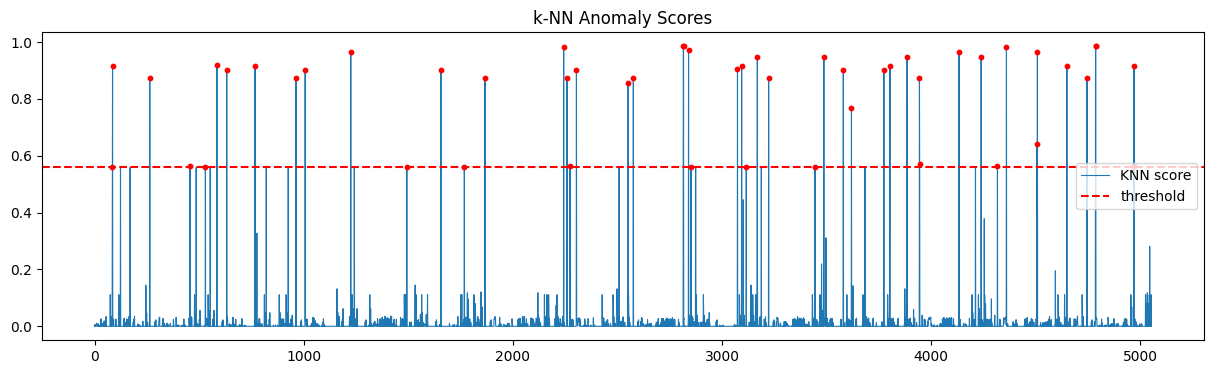

Runtime: 0.157s
Outliers detected: 51


In [208]:
f_7 = np.load("data/data/data/test/F-7.npy")
results = k_NN_calc(f_7, num_neighbors=60)


#### LOF

In [ ]:
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import numpy as np
import pandas as pd

def detect_anomalies(test_data, train_data, channel, anomaly_sequences, gap_threshold=10):
    """
    Unified anomaly detection pipeline for a single channel.
    Runs IQR, k-NN, LOF on the test data.
    Returns a DataFrame of results per method.
    """
    
    methods_results = {}
    
    # ground truth label vector
    true_labels = create_label_vector(len(test_data), anomaly_sequences)
    
    # ─────────────────────────────────────────
    # METHOD 3 — LOF (multivariate)
    # ─────────────────────────────────────────
    start = time.time()
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    lof.fit_predict(X)
    lof_scores = -lof.negative_outlier_factor_
    lof_labels = scores_to_labels(lof_scores)
    lof_time = time.time() - start
    methods_results['LOF'] = {
        'scores': lof_scores,
        'predicted_labels': lof_labels,
        'runtime': round(lof_time, 4)
    }
    
    # ─────────────────────────────────────────
    # EVALUATE ALL METHODS
    # ─────────────────────────────────────────
    results = []
    for method_name, method_data in methods_results.items():
        predicted_labels = method_data['predicted_labels']
        predicted_windows = merge_to_windows(predicted_labels, gap_threshold)
        
        metrics = evaluate(
            true_labels, 
            predicted_labels,
            anomaly_sequences,
            predicted_windows
        )
        
        results.append({
            'channel': channel,
            'method': method_name,
            'runtime': method_data['runtime'],
            **metrics
        })
    
    return pd.DataFrame(results)


# ─────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────
def scores_to_labels(scores, threshold_percentile=99):
    """Convert anomaly scores to binary labels"""
    threshold = np.percentile(scores, threshold_percentile)
    return (scores >= threshold).astype(int)


def create_label_vector(num_values, anomaly_sequences):
    """Convert anomaly windows to binary vector"""
    labels = np.zeros(num_values)
    for start, end in anomaly_sequences:
        labels[start:end] = 1
    return labels


def merge_to_windows(predicted_labels, gap_threshold=10):
    """Merge nearby flagged timesteps into windows"""
    anomaly_timesteps = np.where(predicted_labels == 1)[0]
    if len(anomaly_timesteps) == 0:
        return []
    windows = []
    start = anomaly_timesteps[0]
    end = anomaly_timesteps[0]
    for t in anomaly_timesteps[1:]:
        if t - end <= gap_threshold:
            end = t
        else:
            windows.append([int(start), int(end)])
            start = t
            end = t
    windows.append([int(start), int(end)])
    return windows


def evaluate(true_labels, predicted_labels, true_windows, predicted_windows):
    """Compute all metrics"""
    return {
        'precision': precision_score(true_labels, predicted_labels, zero_division=0),
        'recall': recall_score(true_labels, predicted_labels, zero_division=0),
        'f1': f1_score(true_labels, predicted_labels, zero_division=0),
        'event_detection_rate': event_detection_rate(true_windows, predicted_windows)
    }


def event_detection_rate(true_windows, predicted_windows):
    """Fraction of true anomaly windows detected"""
    if len(true_windows) == 0:
        return 1.0
    detected = 0
    for true_start, true_end in true_windows:
        for pred_start, pred_end in predicted_windows:
            if pred_start <= true_end and pred_end >= true_start:
                detected += 1
                break
    return detected / len(true_windows)

In [ ]:
all_results = []

for _, row in labeled_data.iterrows():
    channel = row['chan_id']
    spacecraft = row['spacecraft']
    anomaly_sequences = row['anomaly_sequences_parsed']
    anomaly_type = parse_class(row['class'])
    
    # determine overall type for this channel
    unique_types = set(anomaly_type)
    if len(unique_types) > 1:
        channel_type = 'mixed'
    else:
        channel_type = anomaly_type[0]
    
    # load data
    test_data = np.load(f"data/data/data/test/{channel}.npy")
    train_data = np.load(f"data/data/data/train/{channel}.npy")
    
    print(f"Processing {channel} ({spacecraft}, {channel_type})...")
    
    channel_results = detect_anomalies(
        test_data, train_data, channel, anomaly_sequences
    )
    channel_results['spacecraft'] = spacecraft
    channel_results['anomaly_type'] = channel_type
    
    all_results.append(channel_results)

# combine everything
final_results = pd.concat(all_results, ignore_index=True)
print(final_results)

In [195]:
# overall by method
print(final_results.groupby('method')[['precision','recall','f1','event_detection_rate','runtime']].mean().round(3))

# by anomaly type — your core hypothesis test
print(final_results.groupby(['method','anomaly_type'])[['precision','recall','f1']].mean().round(3))

        precision  recall     f1  event_detection_rate  runtime
method                                                         
IQR         0.365   0.215  0.181                 0.667    0.000
LOF         0.149   0.155  0.051                 0.874    0.038
kNN         0.152   0.233  0.061                 0.854    0.034
                     precision  recall     f1
method anomaly_type                          
IQR    contextual        0.104   0.155  0.078
       mixed             0.202   0.133  0.159
       point             0.508   0.252  0.234
LOF    contextual        0.172   0.051  0.044
       mixed             0.115   0.262  0.036
       point             0.140   0.198  0.056
kNN    contextual        0.157   0.134  0.068
       mixed             0.121   0.261  0.036
       point             0.152   0.281  0.059
